In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns #

In [2]:
from sqlalchemy import create_engine

username = 'Equipo18'
password = 'E1q2u3i4p5o18'
host = '212.227.90.6'
database = 'Equip_18'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

In [3]:
from sqlalchemy import inspect
inspector = inspect(engine)

tables = inspector.get_table_names()

for table in tables:
    df = pd.read_sql(f"SELECT * FROM {table}", engine)
    globals()[f'df_{table}'] = df  

In [31]:
df_BANK_marketing03112025.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Estadisticas

In [32]:
df_BANK_marketing03112025.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,16172.000000,16159.000000,16172.000000,16172.000000,16172.000000,16172.000000,16172.000000,16172.000000
mean,9694.508286,41.313757,1535.560846,15.672211,370.724215,2.512367,51.422830,0.834776
std,6754.343590,11.930580,3292.287543,8.438215,347.402533,2.736060,109.462056,2.288949
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,4039.750000,32.000000,124.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,8078.500000,39.000000,556.000000,15.000000,254.000000,2.000000,-1.000000,0.000000
75%,17341.250000,49.000000,1708.000000,22.000000,494.000000,3.000000,9.000000,1.000000
max,21383.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


Correlaciones

               age   balance       day  duration  campaign  previous
age       1.000000  0.117401  0.006993 -0.002484 -0.007285  0.016407
balance   0.117401  1.000000  0.011783  0.021323 -0.017868  0.028838
day       0.006993  0.011783  1.000000 -0.019440  0.136816 -0.059387
duration -0.002484  0.021323 -0.019440  1.000000 -0.047833 -0.027693
campaign -0.007285 -0.017868  0.136816 -0.047833  1.000000 -0.051563
previous  0.016407  0.028838 -0.059387 -0.027693 -0.051563  1.000000


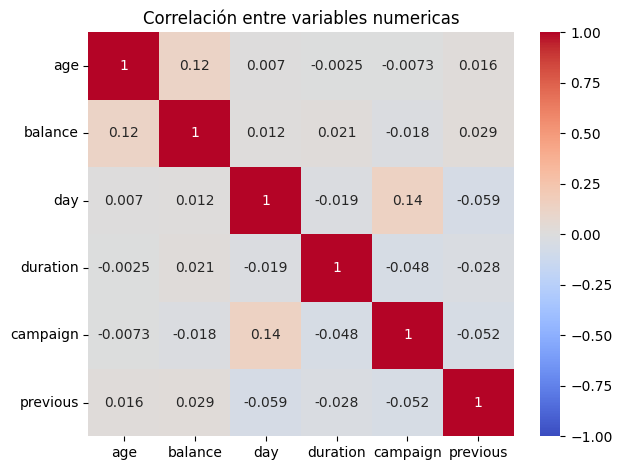

In [ ]:
df_varnumericas = df_BANK_marketing03112025[['age', 'balance', 'day', 'duration', 'campaign', 'previous']] 
correlation = df_varnumericas.corr() #saco la correlacion
print(correlation)

sns.heatmap(correlation,
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1)      # aca defino la escala de correlacion

plt.title('Correlación entre variables numericas', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Histogramas

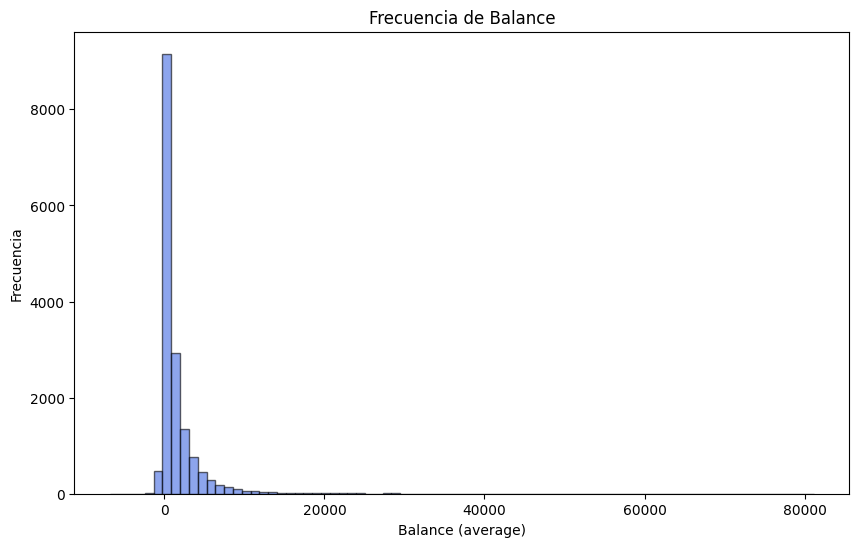

In [34]:
fig, ax = plt.subplots(figsize=(10, 6)) 

df_BANK_marketing03112025["balance"].plot.hist(bins=80,
                                         color='royalblue',
                                        edgecolor='black',
                                        alpha=0.6,
                                        ax=ax)


ax.set_title("Frecuencia de Balance")
ax.set_xlabel("Balance (average)")
ax.set_ylabel("Frecuencia")

plt.show()

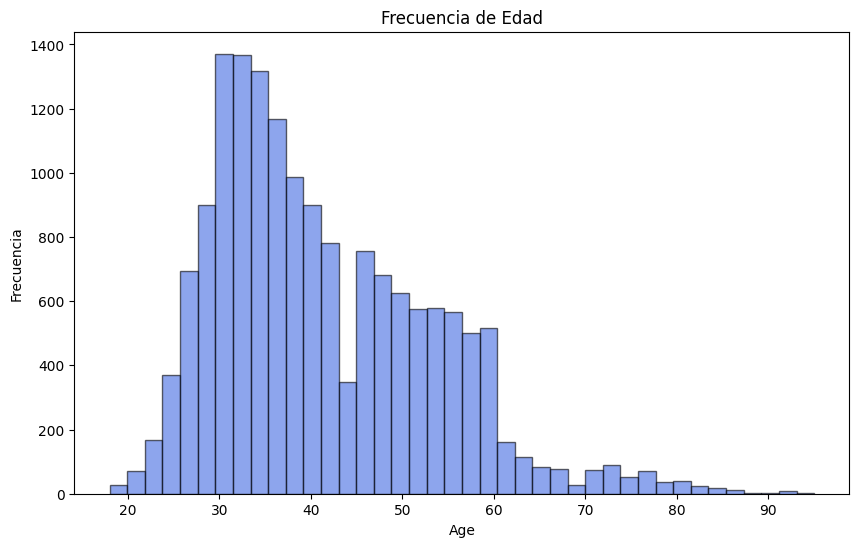

In [35]:
fig, ax = plt.subplots(figsize=(10, 6)) 

df_BANK_marketing03112025["age"].plot.hist(bins=40,
                                         color='royalblue',
                                        edgecolor='black',
                                        alpha=0.6,
                                        ax=ax)


ax.set_title("Frecuencia de Edad")
ax.set_xlabel("Age")
ax.set_ylabel("Frecuencia")
plt.show()

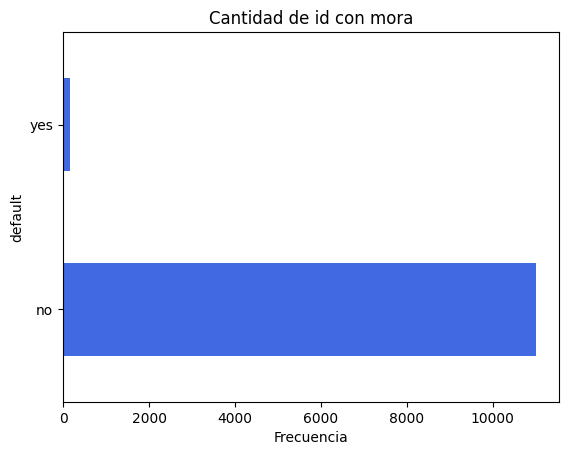

In [ ]:
df_BANK_marketing03112025["default"].value_counts().plot.barh(color='royalblue',            
                                                 title="Cantidad de id con mora",
                                                 xlabel="Frecuencia");

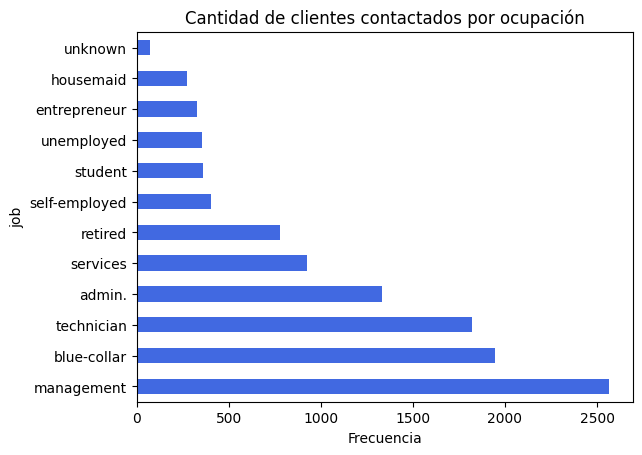

In [ ]:
df_BANK_marketing03112025["job"].value_counts().plot.barh(color='royalblue',            
                                                 title="Cantidad de clientes contactados por ocupación",
                                                 xlabel="Frecuencia");

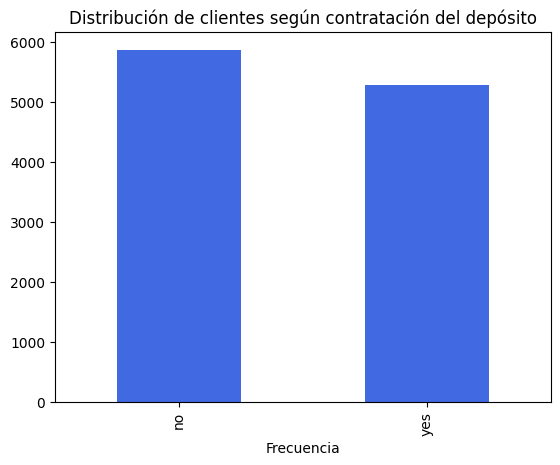

In [ ]:

df_BANK_marketing03112025["deposit"].value_counts().plot.bar(color='royalblue',            
                                                 title="Distribución de clientes según contratación del depósito",
                                                 xlabel="Frecuencia");